In [ ]:
import numpy as np

def N_along_c(a, b, c):
    """Aharoni demag factor along the c half-axis of a 2a x 2b x 2c prism."""
    r  = np.sqrt(a**2 + b**2 + c**2)
    ab = np.sqrt(a**2 + b**2); bc = np.sqrt(b**2 + c**2); ac = np.sqrt(a**2 + c**2)
    N = ((b**2 - c**2)/(2*b*c) * np.log((r - a)/(r + a))
       + (a**2 - c**2)/(2*a*c) * np.log((r - b)/(r + b))
       + b/(2*c) * np.log((ab + a)/(ab - a))
       + a/(2*c) * np.log((ab + b)/(ab - b))
       + c/(2*a) * np.log((bc - b)/(bc + b))
       + c/(2*b) * np.log((ac - a)/(ac + a))
       + 2*np.arctan2(a*b, c*r)
       + (a**3 + b**3 - 2*c**3)/(3*a*b*c)
       + (a**2 + b**2 - 2*c**2)*r/(3*a*b*c)
       + c/(a*b)*(ac + bc)
       - (ab**3 + bc**3 + ac**3)/(3*a*b*c))
    return N/np.pi

# half-dimensions: Lx/2, Ly/2, tFL/2
ax, ay, az = 75e-9, 25e-9, 0.85e-9
Nxx = N_along_c(ay, az, ax)
Nyy = N_along_c(ax, az, ay)
Nzz = N_along_c(ax, ay, az)
print(f"Nxx={Nxx:.4f}  Nyy={Nyy:.4f}  Nzz={Nzz:.4f}  sum={Nxx+Nyy+Nzz:.4f}")

Nxx=0.0159  Nyy=0.0496  Nzz=0.9345  sum=1.0000


Saving 5. VCMA 0-3V fine.txt to 5. VCMA 0-3V fine.txt
3131 runs | Vwrite 0.0-3.0 V | tpulse 0.00-2.00 ns

Widest contiguous switched (mz<0) window per Vwrite:
  Vwrite=0.00 V :  0 cells = 0.000 ns  (no window)
  Vwrite=0.10 V :  0 cells = 0.000 ns  (no window)
  Vwrite=0.20 V :  0 cells = 0.000 ns  (no window)
  Vwrite=0.30 V :  0 cells = 0.000 ns  (no window)
  Vwrite=0.40 V :  0 cells = 0.000 ns  (no window)
  Vwrite=0.50 V :  0 cells = 0.000 ns  (no window)
  Vwrite=0.60 V : 89 cells = 1.780 ns  (tpulse 0.24-2.00 ns)
  Vwrite=0.70 V : 92 cells = 1.840 ns  (tpulse 0.18-2.00 ns)
  Vwrite=0.80 V : 26 cells = 0.520 ns  (tpulse 0.16-0.66 ns)
  Vwrite=0.90 V : 42 cells = 0.840 ns  (tpulse 1.18-2.00 ns)
  Vwrite=1.00 V : 29 cells = 0.580 ns  (tpulse 1.08-1.64 ns)
  Vwrite=1.10 V : 26 cells = 0.520 ns  (tpulse 1.02-1.52 ns)
  Vwrite=1.20 V : 19 cells = 0.380 ns  (tpulse 1.08-1.44 ns)
  Vwrite=1.30 V : 17 cells = 0.340 ns  (tpulse 1.06-1.38 ns)
  Vwrite=1.40 V : 16 cells = 0.320 ns  (tpulse 

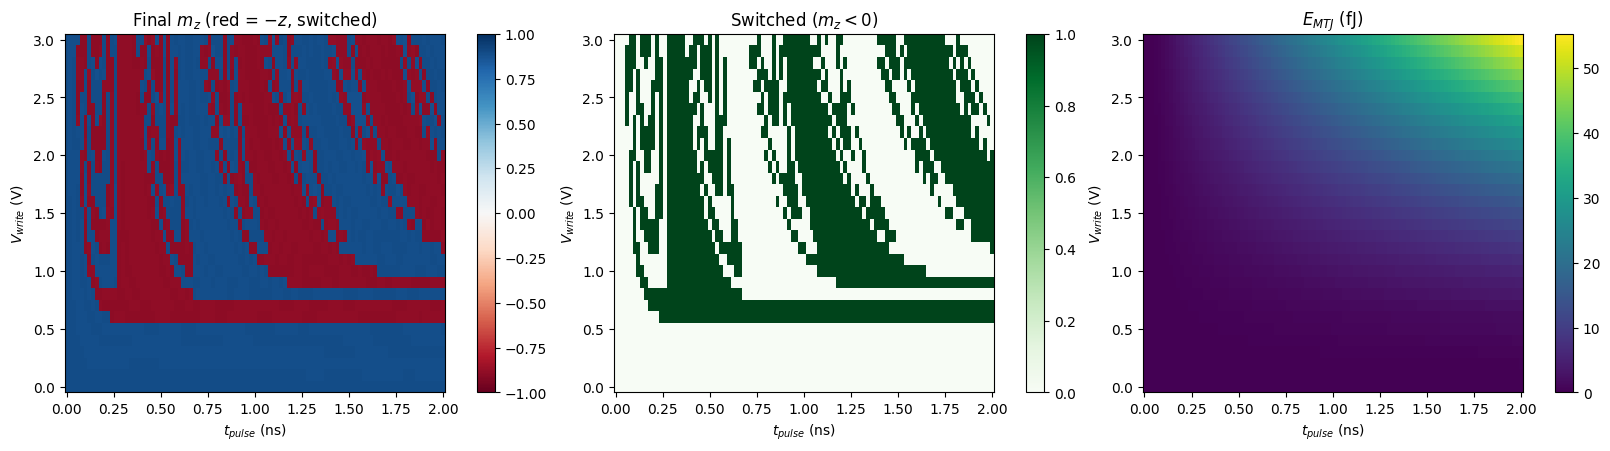

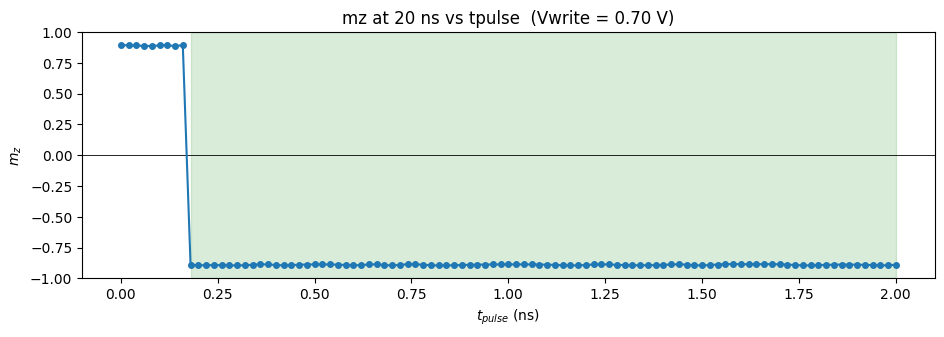

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, io
from google.colab import files

# --- upload the COMSOL export ---
uploaded = files.upload()
fname = next(iter(uploaded))

# columns in this export: Vwrite, tpulse, Time, at(20e-9,mz), at(20e-9,EMTJ), mz<0
cols = ["Vwrite", "tpulse", "time", "mz_final", "EMTJ", "sw_hemi"]
df = pd.read_csv(io.BytesIO(uploaded[fname]), comment="%", sep=r"\s+",
                 header=None, names=cols)

df = df.drop(columns="time")
df["tpulse_ns"] = df["tpulse"] * 1e9
df["EMTJ_fJ"]   = df["EMTJ"]   * 1e15
df = df.sort_values(["Vwrite", "tpulse"]).reset_index(drop=True)
print(f"{len(df)} runs | Vwrite {df.Vwrite.min()}-{df.Vwrite.max()} V | "
      f"tpulse {df.tpulse_ns.min():.2f}-{df.tpulse_ns.max():.2f} ns")

# --- pivot to grids ---
mz = df.pivot(index="Vwrite", columns="tpulse_ns", values="mz_final")
sw = df.pivot(index="Vwrite", columns="tpulse_ns", values="sw_hemi")
en = df.pivot(index="Vwrite", columns="tpulse_ns", values="EMTJ_fJ")
V, T = mz.index.values, mz.columns.values
dt = np.median(np.diff(T))            # tpulse step, ns

def edges(x):
    x = np.asarray(x, float)
    return np.r_[x[0]-(x[1]-x[0])/2, (x[:-1]+x[1:])/2, x[-1]+(x[-1]-x[-2])/2]
Te, Ve = edges(T), edges(V)

# --- key metric: widest CONTIGUOUS switched window per Vwrite ---
def longest_run(mask):
    best = cur = start = best_start = 0
    for i, x in enumerate(mask):
        if x:
            if cur == 0: start = i
            cur += 1
            if cur > best: best, best_start = cur, start
        else:
            cur = 0
    return best, best_start

print("\nWidest contiguous switched (mz<0) window per Vwrite:")
results = []
for v in V:
    m = sw.loc[v].values.astype(bool)
    run, s0 = longest_run(m)
    width = run * dt
    t0 = T[s0] if run else np.nan
    t1 = T[s0+run-1] if run else np.nan
    results.append((v, run, width, t0, t1))
    print(f"  Vwrite={v:.2f} V : {run:2d} cells = {width:.3f} ns"
          + (f"  (tpulse {t0:.2f}-{t1:.2f} ns)" if run else "  (no window)"))

best = max(results, key=lambda r: r[1])
print(f"\nWidest window overall: {best[2]:.3f} ns at Vwrite={best[0]:.2f} V, "
      f"tpulse {best[3]:.2f}-{best[4]:.2f} ns")
JITTER = 0.10  # ns, project spec upper bound
print("VERDICT:", "jitter-robust window exists" if best[2] >= JITTER
      else f"NO jitter-robust window (widest {best[2]:.3f} ns < {JITTER} ns "
           "spec) -> precessional VCMA-only insufficient, motivates SOT co-design")

# --- maps ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
p0 = ax[0].pcolormesh(Te, Ve, mz.values, cmap="RdBu", vmin=-1, vmax=1)
ax[0].set_title(r"Final $m_z$ (red = $-z$, switched)"); fig.colorbar(p0, ax=ax[0])
p1 = ax[1].pcolormesh(Te, Ve, sw.values, cmap="Greens", vmin=0, vmax=1)
ax[1].set_title(r"Switched ($m_z<0$)"); fig.colorbar(p1, ax=ax[1])
p2 = ax[2].pcolormesh(Te, Ve, en.values, cmap="viridis")
ax[2].set_title(r"$E_{MTJ}$ (fJ)"); fig.colorbar(p2, ax=ax[2])
for a in ax:
    a.set_xlabel(r"$t_{pulse}$ (ns)"); a.set_ylabel(r"$V_{write}$ (V)")
plt.show()

# --- zoom: mz vs tpulse at the best Vwrite, to see the alternation directly ---
plt.figure(figsize=(11, 3.2))
row = mz.loc[best[0]]
plt.axhline(0, color="k", lw=0.6)
plt.plot(row.index, row.values, "o-", ms=4)
plt.fill_between(row.index, -1, 1, where=(sw.loc[best[0]].values > 0),
                 color="green", alpha=0.15, step="mid")
plt.title(f"mz at 20 ns vs tpulse  (Vwrite = {best[0]:.2f} V)")
plt.xlabel(r"$t_{pulse}$ (ns)"); plt.ylabel(r"$m_z$"); plt.ylim(-1, 1)
plt.show()